In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [91]:
query = select(Feedback.json, Feedback.round_id, Feedback.datetime).filter(
    Feedback.key_name == 'TDM_quitouts',
    Feedback.datetime >= datetime(2023, 9, 1))

In [92]:
df = pd.read_sql_query(query, session.connection())

In [93]:
def tdm_quitouts(x):
    total = 0
    for k in x['data'].values():
        total += sum(k.values())
    return {'quitouts': total}


In [94]:
df

,json,round_id,datetime
0,{'data': {'nuclear emergency': {'TDM Cryopods'...,37379,2023-09-20 15:19:18
1,{'data': {'wizard': {'TDM Cryopods': 7}}},37374,2023-09-20 05:26:14
2,{'data': {'nuclear emergency': {'TDM Cryopods'...,37372,2023-09-20 02:30:26
3,{'data': {'ragin' mages': {'TDM Cryopods': 11}}},37371,2023-09-20 01:10:21
4,{'data': {'wizard': {'TDM Cryopods': 2}}},37386,2023-09-21 03:30:49
...,...,...,...
490,{'data': {'wizard': {'TDM Cryopods': 4}}},41557,2024-08-23 22:58:52
491,{'data': {'nuclear emergency': {'TDM Suicides'...,41554,2024-08-23 17:40:50
492,{'data': {'nuclear emergency': {'TDM Cryopods'...,41545,2024-08-22 22:01:52
493,"{'data': {'wizard': {'TDM Cryopods': 1, 'TDM S...",41544,2024-08-22 21:45:25


In [95]:
df.join(pd.json_normalize(df.json.map(tdm_quitouts))).drop(['json'], axis=1)

,round_id,datetime,quitouts
0,37379,2023-09-20 15:19:18,11
1,37374,2023-09-20 05:26:14,7
2,37372,2023-09-20 02:30:26,13
3,37371,2023-09-20 01:10:21,11
4,37386,2023-09-21 03:30:49,2
...,...,...,...
490,41557,2024-08-23 22:58:52,4
491,41554,2024-08-23 17:40:50,11
492,41545,2024-08-22 22:01:52,7
493,41544,2024-08-22 21:45:25,2


In [96]:
df = df.join(pd.json_normalize(df.json.map(tdm_quitouts))).drop(['json'], axis=1)
df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
df.drop(['datetime'], inplace=True, axis=1)

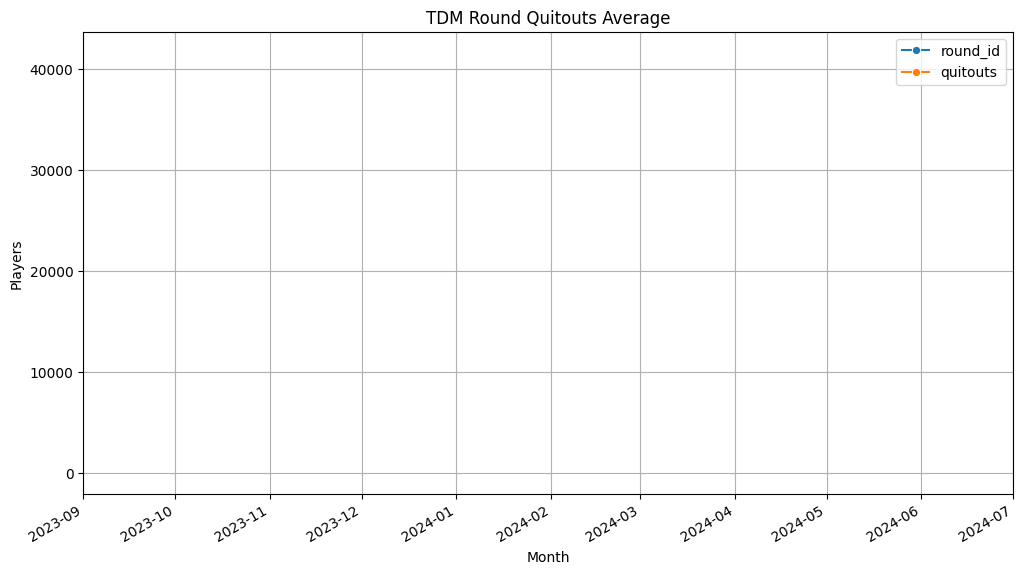

In [99]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
plot = sns.lineplot(
    data=df,
    marker='o',
    linestyle='solid',
    dashes=False,
)
plot.set(xlim=(date(2023, 9, 1), date(2024, 7, 1)))
plot.set(title='TDM Round Quitouts Average')
plot.set(xlabel='Month', ylabel='Players')
months = mdates.MonthLocator(interval=1) 
ax.xaxis.set_major_locator(months)

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax.grid()
plt.savefig("tdm_cowards_total.png")